# BraTS 2024 Exploratory Data Analysis

In [1]:
import nibabel as nib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
!git clone -b minvalue_norm https://github.com/AdaBro24/BraTS_thesis.git /content/BraTS_thesis

fatal: destination path '/content/BraTS_thesis' already exists and is not an empty directory.


In [3]:
!git -C /content/BraTS_thesis fetch origin
!git -C /content/BraTS_thesis checkout minvalue_norm
!git -C /content/BraTS_thesis pull origin minvalue_norm
!pip install -e /content/BraTS_thesis

Already on 'minvalue_norm'
Your branch is up to date with 'origin/minvalue_norm'.
From https://github.com/AdaBro24/BraTS_thesis
 * branch            minvalue_norm -> FETCH_HEAD
Already up to date.
Obtaining file:///content/BraTS_thesis
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for brain_mri (pyproject.toml) ... done
  Created wheel for brain_mri: filename=brain_mri-0.1.0-0.editable-py3-none-any.whl size=1298 sha256=5ce514c430ac2fa79036ea9ad12a58de43bf40d8b292b50134579c4c53af5eb2
  Stored in directory: /tmp/pip-ephem-wheel-cache-_izwlx9r/wheels/4b/5c/05/dacf53db21b47a84a06f984d5251964e1c2594931cea5ebbaa
Successfully built brain_mri
  Attempting uninstall: brain_mri
    Found existing installation: brain_mri 0.1.0
    Uninstalling brain_mri-0.1.0:
      Successfully uninstalled brain_mri-0.1.0


In [4]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data paths and setup

In [5]:
from pathlib import Path
import zipfile

ZIP_DIR = Path("/content/drive/MyDrive/engineering_thesis/brats")
GLI_ZIP = ZIP_DIR / "BraTS2024-BraTS-GLI-TrainingData.zip"
MEN_ZIP = ZIP_DIR / "BraTS2024-MEN-RT-TrainingData.zip"

DATA_ROOT = ZIP_DIR / "unpacked"

"""for zip_path, dataset_name in [(GLI_ZIP, "BraTS-GLI"), (MEN_ZIP, "BraTS-MEN")]:
    target_dir = DATA_ROOT / dataset_name
    if not target_dir.exists():
        target_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path) as archive:
            archive.extractall(target_dir)
        print(f"Unpacked: {dataset_name}")
    else:
        print(f"Directory already exists: {target_dir}")"""

GLI_ROOT = DATA_ROOT / "BraTS-GLI" / "training_data1_v2"
MEN_ROOT = DATA_ROOT / "BraTS-MEN" / "BraTS-MEN-RT-Train-v2"

In [6]:
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

MODALITY_SUFFIXES = {
    "T1" : "t1n",
    "T1CE" : "t1c",
    "T2" : "t2w",
    "FLAIR" : "t2f",
    "SEG" : "seg",
}

SEG_LABELS = {
    1: "NETC",
    2: "SNFH",
    3: "ET",
    4: "RC",
}

SEG_COLORS = {
    1: "#7B2CBF",
    2: "#1F9E89",
    3: "#57C95A",
    4: "#FDE725",
}

SEG_CMAP = ListedColormap([SEG_COLORS[label] for label in SEG_LABELS])
SEG_NORM = BoundaryNorm(
    boundaries=[0.5, 1.5, 2.5, 3.5, 4.5],
    ncolors=SEG_CMAP.N,
)

SEG_LEGEND = [
    Patch(facecolor=SEG_COLORS[label], label=f"{label}: {name}")
    for label, name in SEG_LABELS.items()
]

In [7]:
def find_patient_files(patient_dir : Path) -> dict:
    patient_files = {}

    for file_path in patient_dir.iterdir():
        if not file_path.is_file():
            continue

        name_without_ext = file_path.name.replace(".nii.gz", "").replace(".nii", "").lower()

        for modality, suffix in MODALITY_SUFFIXES.items():
            if name_without_ext.endswith(suffix):
                patient_files[modality] = file_path
                break

    return patient_files

def list_patient_dirs(data_dir: Path) -> list[Path]:
    patient_dirs = []

    for entry in data_dir.iterdir():
        if entry.is_dir():
            patient_dirs.append(entry)

    return patient_dirs

sample_dir = list_patient_dirs(GLI_ROOT)[0]
sample_files = find_patient_files(sample_dir)



print("Patient:", sample_dir.name)
print("Patient files:", sample_files)

Patient: BraTS-GLI-02800-101
Patient files: {'SEG': PosixPath('/content/drive/MyDrive/engineering_thesis/brats/unpacked/BraTS-GLI/training_data1_v2/BraTS-GLI-02800-101/BraTS-GLI-02800-101-seg.nii.gz'), 'T1CE': PosixPath('/content/drive/MyDrive/engineering_thesis/brats/unpacked/BraTS-GLI/training_data1_v2/BraTS-GLI-02800-101/BraTS-GLI-02800-101-t1c.nii.gz'), 'T1': PosixPath('/content/drive/MyDrive/engineering_thesis/brats/unpacked/BraTS-GLI/training_data1_v2/BraTS-GLI-02800-101/BraTS-GLI-02800-101-t1n.nii.gz'), 'FLAIR': PosixPath('/content/drive/MyDrive/engineering_thesis/brats/unpacked/BraTS-GLI/training_data1_v2/BraTS-GLI-02800-101/BraTS-GLI-02800-101-t2f.nii.gz'), 'T2': PosixPath('/content/drive/MyDrive/engineering_thesis/brats/unpacked/BraTS-GLI/training_data1_v2/BraTS-GLI-02800-101/BraTS-GLI-02800-101-t2w.nii.gz')}


In [11]:

from brain_mri.data.nifti_loader import load_patient, find_patient_files
from brain_mri.slice_extraction import (
    process_single_slice,
    get_slice_indices,
    extract_patient_slices,
)
from pathlib import Path
import numpy as np

patient_dir = GLI_ROOT / "BraTS-GLI-00005-100"
images, segmentation = load_patient(patient_dir)

print("Images shape:", images.shape)
print("Images dtype:", images.dtype)
print("SEG shape:", segmentation.shape)
print("SEG dtype:", segmentation.dtype)
print("SEG labels:", np.unique(segmentation))

Images shape: (4, 182, 218, 182)
Images dtype: float32
SEG shape: (182, 218, 182)
SEG dtype: int16
SEG labels: [0 2 4]


In [12]:
from pathlib import Path
boundaries_path = Path("/content/BraTS_thesis/data/patients_z_boundaries.json")
slices = extract_patient_slices(patient_dir, boundaries_path)

print(slices[0]["image"].shape)
print(slices[0]["mask"].shape)

(4, 224, 224)
(224, 224)


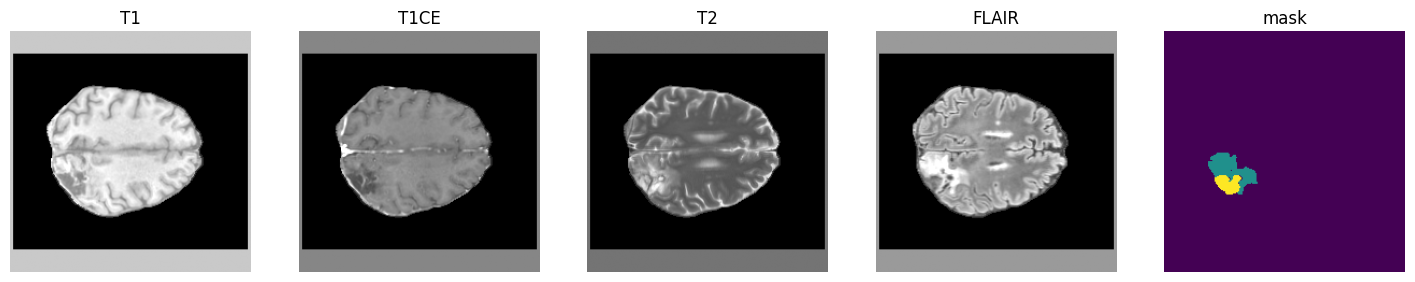

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [13]:
import matplotlib.pyplot as plt

best_slice = max(slices, key=lambda s: (s["mask"] != 0).sum())

fig, axes = plt.subplots(1, 5, figsize=(18,4))
modality_names = ["T1", "T1CE", "T2", "FLAIR"]

for i, name in enumerate(modality_names):
    axes[i].imshow(best_slice["image"][i], cmap="gray")
    axes[i].set_title(name)
    axes[i].axis("off")

axes[4].imshow(best_slice["mask"], cmap="viridis")
axes[4].set_title("mask")
axes[4].axis("off")
plt.show()

best_slice["image"][0]

In [10]:
arr = best_slice["image"][0]
print("shape:", arr.shape)
print("min:", arr.min(), "max:", arr.max())
print("mean:", arr.mean(), "std:", arr.std())
print("how many zeros:", (arr == 0).sum(), "/", arr.size)
print("unique values:", np.unique(arr)[:10])

shape: (224, 224)
min: -3.8576572 max: 1.3213116
mean: 0.014479459 std: 0.47921863
how many zeros: 36500 / 50176
unique values: [-3.8576572 -3.8574893 -3.8557072 -3.8472774 -3.8465378 -3.8455973
 -3.8391988 -3.8252137 -3.821949  -3.8070605]


In [11]:
print("Upper row:", np.unique(arr[0, :]))
print("Lower row:", np.unique(arr[-1, :]))

print("Left upper:", np.unique(arr[:25, :25]))

Upper row: [0.]
Lower row: [0.]
Left upper: [0.]


min pixels count: 119
Random xy: [(np.int64(51), np.int64(87)), (np.int64(54), np.int64(116)), (np.int64(55), np.int64(120)), (np.int64(56), np.int64(122)), (np.int64(62), np.int64(143)), (np.int64(63), np.int64(145)), (np.int64(64), np.int64(147)), (np.int64(65), np.int64(150)), (np.int64(66), np.int64(151)), (np.int64(66), np.int64(152))]


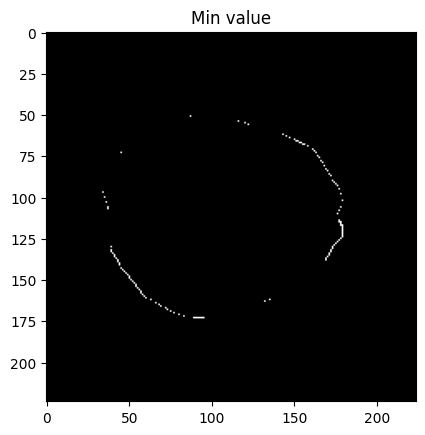

In [12]:
# ile pikseli ma wartość -0.43771005 w całym slice?
print("min pixels count:", (arr == arr.min()).sum())

# gdzie one są? (współrzędne)
ys, xs = np.where(arr == arr.min())
print("Random xy:", list(zip(ys[:10], xs[:10])))

# czy to jest skupione w jednym miejscu, czy rozproszone po całym obrazie?
import matplotlib.pyplot as plt
plt.imshow(arr == arr.min(), cmap="gray")
plt.title("Min value")
plt.show()

## Dataset overview

In [9]:
gli_patients = list_patient_dirs(GLI_ROOT)
men_patients = list_patient_dirs(MEN_ROOT)

print(f"Total GLI patients: {len(gli_patients)}")
print(f"Total MEN patients: {len(men_patients)}")


Total GLI patients: 1350
Total MEN patients: 500


In [10]:
for modality, file_path in sample_files.items():
    image = nib.load(file_path)

    print(f"\n{modality}")
    print(f"Shape: {image.shape}")

    


SEG
Shape: (182, 218, 182)

T1CE
Shape: (182, 218, 182)

T1
Shape: (182, 218, 182)

FLAIR
Shape: (182, 218, 182)

T2
Shape: (182, 218, 182)


## GLI single-patient exploration

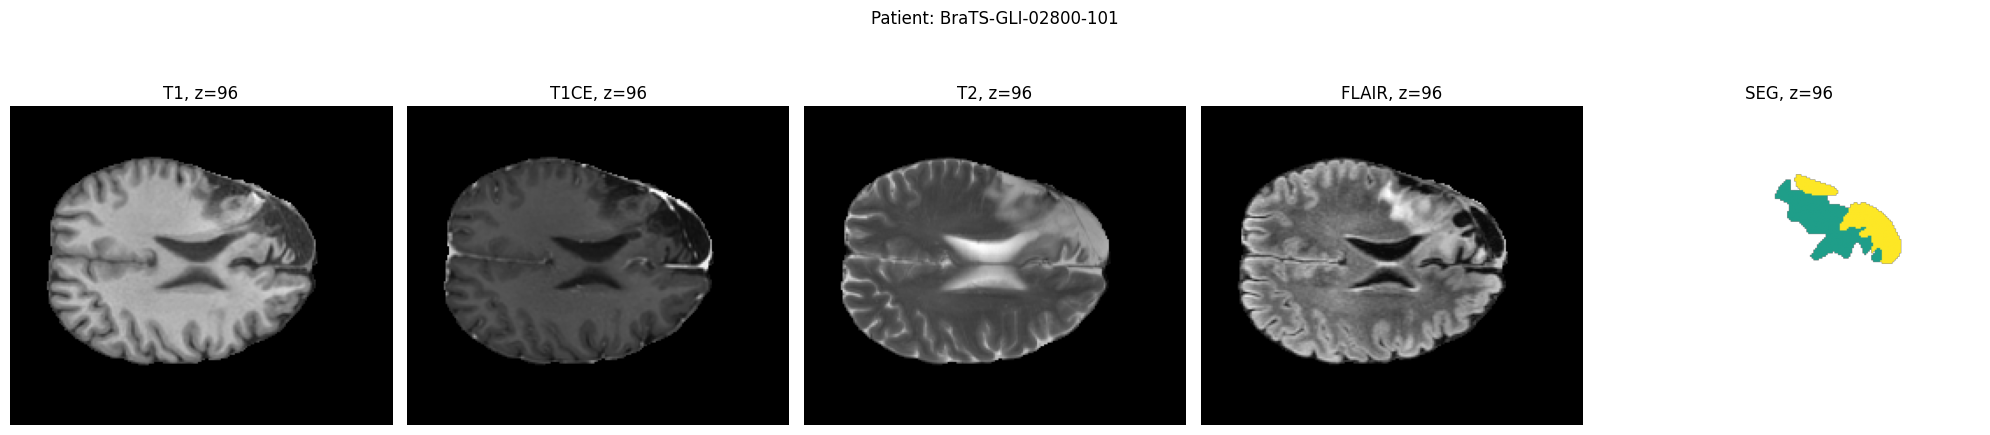

In [11]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

modalities = ["T1", "T1CE", "T2", "FLAIR", "SEG"]
seg_volume = nib.load(sample_files["SEG"]).get_fdata(dtype=np.float32)
slice_idx = np.argmax(np.sum(seg_volume, axis=(0, 1)))

fig, axes = plt.subplots(1, len(modalities), figsize=(20, 5))
for ax, modality in zip(axes, modalities):
    volume = nib.load(sample_files[modality]).get_fdata(dtype=np.float32)

    if modality == "SEG":
        masked_seg = np.ma.masked_where(volume[:, :, slice_idx] == 0, volume[:, :, slice_idx])
        ax.imshow(masked_seg, cmap=SEG_CMAP, norm=SEG_NORM)
    else:
        ax.imshow(volume[:, :, slice_idx], cmap="gray")

    ax.set_title(f"{modality}, z={slice_idx}")
    ax.axis("off")

fig.suptitle(f"Patient: {sample_dir.name}")
plt.tight_layout()
plt.show()

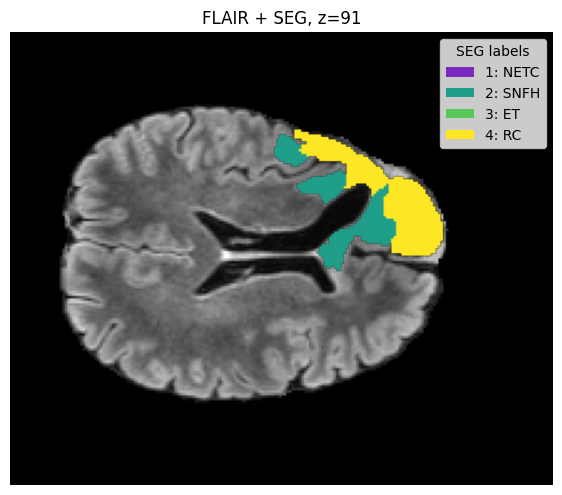

In [12]:
base_modality = "FLAIR"

base_volume = nib.load(sample_files[base_modality]).get_fdata(dtype=np.float32)
seg_volume = nib.load(sample_files["SEG"]).get_fdata(dtype=np.float32)

slice_idx = base_volume.shape[2] // 2

base_slice = base_volume[:, :, slice_idx]
seg_slice = seg_volume[:, :, slice_idx]

masked_seg = np.ma.masked_where(seg_slice == 0, seg_slice)

plt.figure(figsize=(7, 7))
plt.imshow(base_slice, cmap="gray")
plt.imshow(masked_seg, cmap=SEG_CMAP, norm=SEG_NORM, alpha=1.0)
plt.title(f"{base_modality} + SEG, z={slice_idx}")
plt.axis("off")
plt.legend(handles=SEG_LEGEND, loc="upper right", title="SEG labels")
plt.show()

In [13]:
for modality in ["FLAIR", "T1", "T1CE", "T2"]:
    volume = nib.load(sample_files[modality]).get_fdata(dtype=np.float32)
    non_zero_voxels = volume[volume != 0]

    print(f"\n{modality}")
    print(f"shape: {volume.shape}")
    print(f"min: {volume.min()}")
    print(f"max: {volume.max()}")
    print(f"mean: {volume.mean()}")
    print(f"median: {np.median(volume)}")
    print(f"std: {volume.std()}")
    print(f"quantile [0.01, 0.25, 0.5, 0.75, 0.99]: {np.quantile(non_zero_voxels, [0.01, 0.25, 0.5, 0.75, 0.99])}")
    print(f"zero voxels: {(volume==0).sum()}")
    print("nonzero voxels:", len(non_zero_voxels))
    print("NaN:", np.isnan(volume).sum())
    print("inf:", np.isinf(volume).sum())



FLAIR
shape: (182, 218, 182)
min: 0.0
max: 2798.40771484375
mean: 169.48719787597656
median: 0.0
std: 405.55419921875
quantile [0.01, 0.25, 0.5, 0.75, 0.99]: [ 118.31773926  807.24786377 1043.49853516 1270.90332031 1705.82957275]
zero voxels: 6005853
nonzero voxels: 1215179
NaN: 0
inf: 0

T1
shape: (182, 218, 182)
min: 0.0
max: 4949.56689453125
mean: 435.1311950683594
median: 0.0
std: 1016.6055908203125
quantile [0.01, 0.25, 0.5, 0.75, 0.99]: [ 750.35463867 2132.92211914 2696.3605957  3213.46643066 3745.49217285]
zero voxels: 6005853
nonzero voxels: 1215179
NaN: 0
inf: 0

T1CE
shape: (182, 218, 182)
min: 0.0
max: 12051.6669921875
mean: 510.6623229980469
median: 0.0
std: 1202.0284423828125
quantile [0.01, 0.25, 0.5, 0.75, 0.99]: [1004.51953125 2645.70263672 3023.70703125 3456.80029297 7205.28790039]
zero voxels: 6005853
nonzero voxels: 1215179
NaN: 0
inf: 0

T2
shape: (182, 218, 182)
min: 0.0
max: 4870.60009765625
mean: 284.6627197265625
median: 0.0
std: 685.5414428710938
quantile [0.0

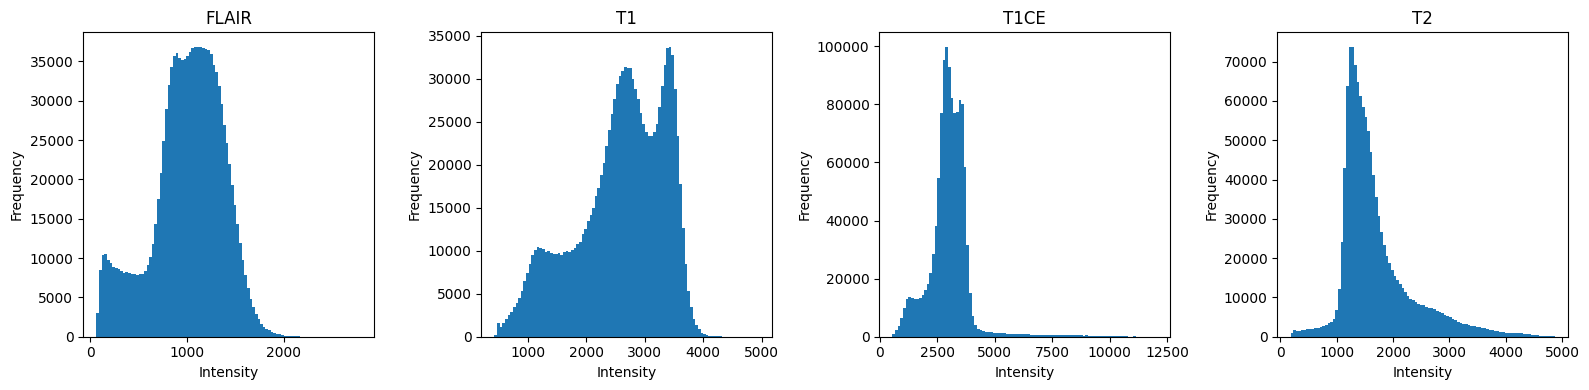

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, modality in zip(axes, ["FLAIR", "T1", "T1CE", "T2"]):
    volume = nib.load(sample_files[modality]).get_fdata(dtype=np.float32)
    non_zero_voxels = volume[volume != 0]

    ax.hist(non_zero_voxels, bins=100)
    ax.set_title(modality)
    ax.set_xlabel("Intensity")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
labels, counts = np.unique(seg_volume, return_counts=True)

for label, count in zip(labels, counts):
    print(f"Label: {label}, Count: {count}")

tumour_voxels_per_slice = np.sum(seg_volume != 0, axis=(0, 1))
best_slice = np.argmax(tumour_voxels_per_slice)
print(f"Best slice with the most tumour voxels: {best_slice}")


Label: 0.0, Count: 7160950
Label: 2.0, Count: 38110
Label: 4.0, Count: 21972
Best slice with the most tumour voxels: 97


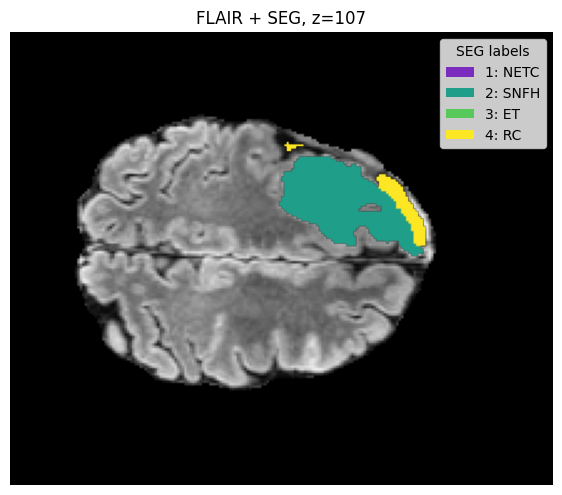

In [16]:
base_modality = "FLAIR"

base_volume = nib.load(sample_files[base_modality]).get_fdata(dtype=np.float32)
seg_volume = nib.load(sample_files["SEG"]).get_fdata(dtype=np.float32)

slice_idx = 107

base_slice = base_volume[:, :, slice_idx]
seg_slice = seg_volume[:, :, slice_idx]

masked_seg = np.ma.masked_where(seg_slice == 0, seg_slice)

plt.figure(figsize=(7, 7))
plt.imshow(base_slice, cmap="gray")
plt.imshow(masked_seg, cmap=SEG_CMAP, norm=SEG_NORM, alpha=1.0)
plt.title(f"{base_modality} + SEG, z={slice_idx}")
plt.axis("off")
plt.legend(handles=SEG_LEGEND, loc="upper right", title="SEG labels")
plt.show()

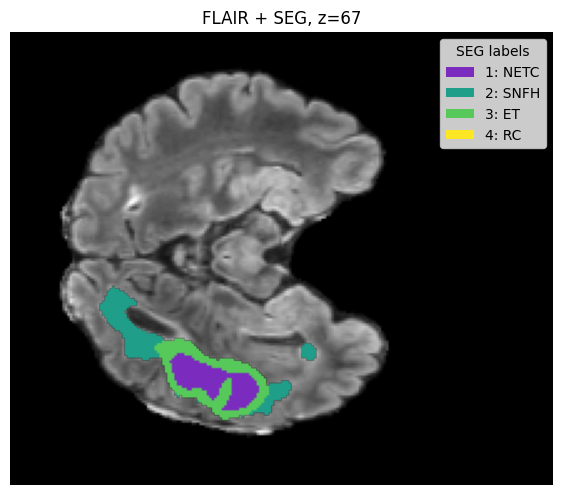

ET voxels: 13195


In [17]:
sample_dir = list_patient_dirs(GLI_ROOT)[1]
sample_files = find_patient_files(sample_dir)

base_modality = "FLAIR"

base_volume = nib.load(sample_files[base_modality]).get_fdata(dtype=np.float32)
seg_volume = nib.load(sample_files["SEG"]).get_fdata(dtype=np.float32)

et_mask = seg_volume == 3
et_slice = np.sum(et_mask, axis=(0, 1))
slice_idx = np.argmax(et_slice)

base_slice = base_volume[:, :, slice_idx]
seg_slice = seg_volume[:, :, slice_idx]

masked_seg = np.ma.masked_where(seg_slice == 0, seg_slice)

plt.figure(figsize=(7, 7))
plt.imshow(base_slice, cmap="gray")
plt.imshow(masked_seg, cmap=SEG_CMAP, norm=SEG_NORM, alpha=1.0)
plt.title(f"{base_modality} + SEG, z={slice_idx}")
plt.axis("off")
plt.legend(handles=SEG_LEGEND, loc="upper right", title="SEG labels")
plt.show()

print("ET voxels:", (seg_volume == 3).sum())

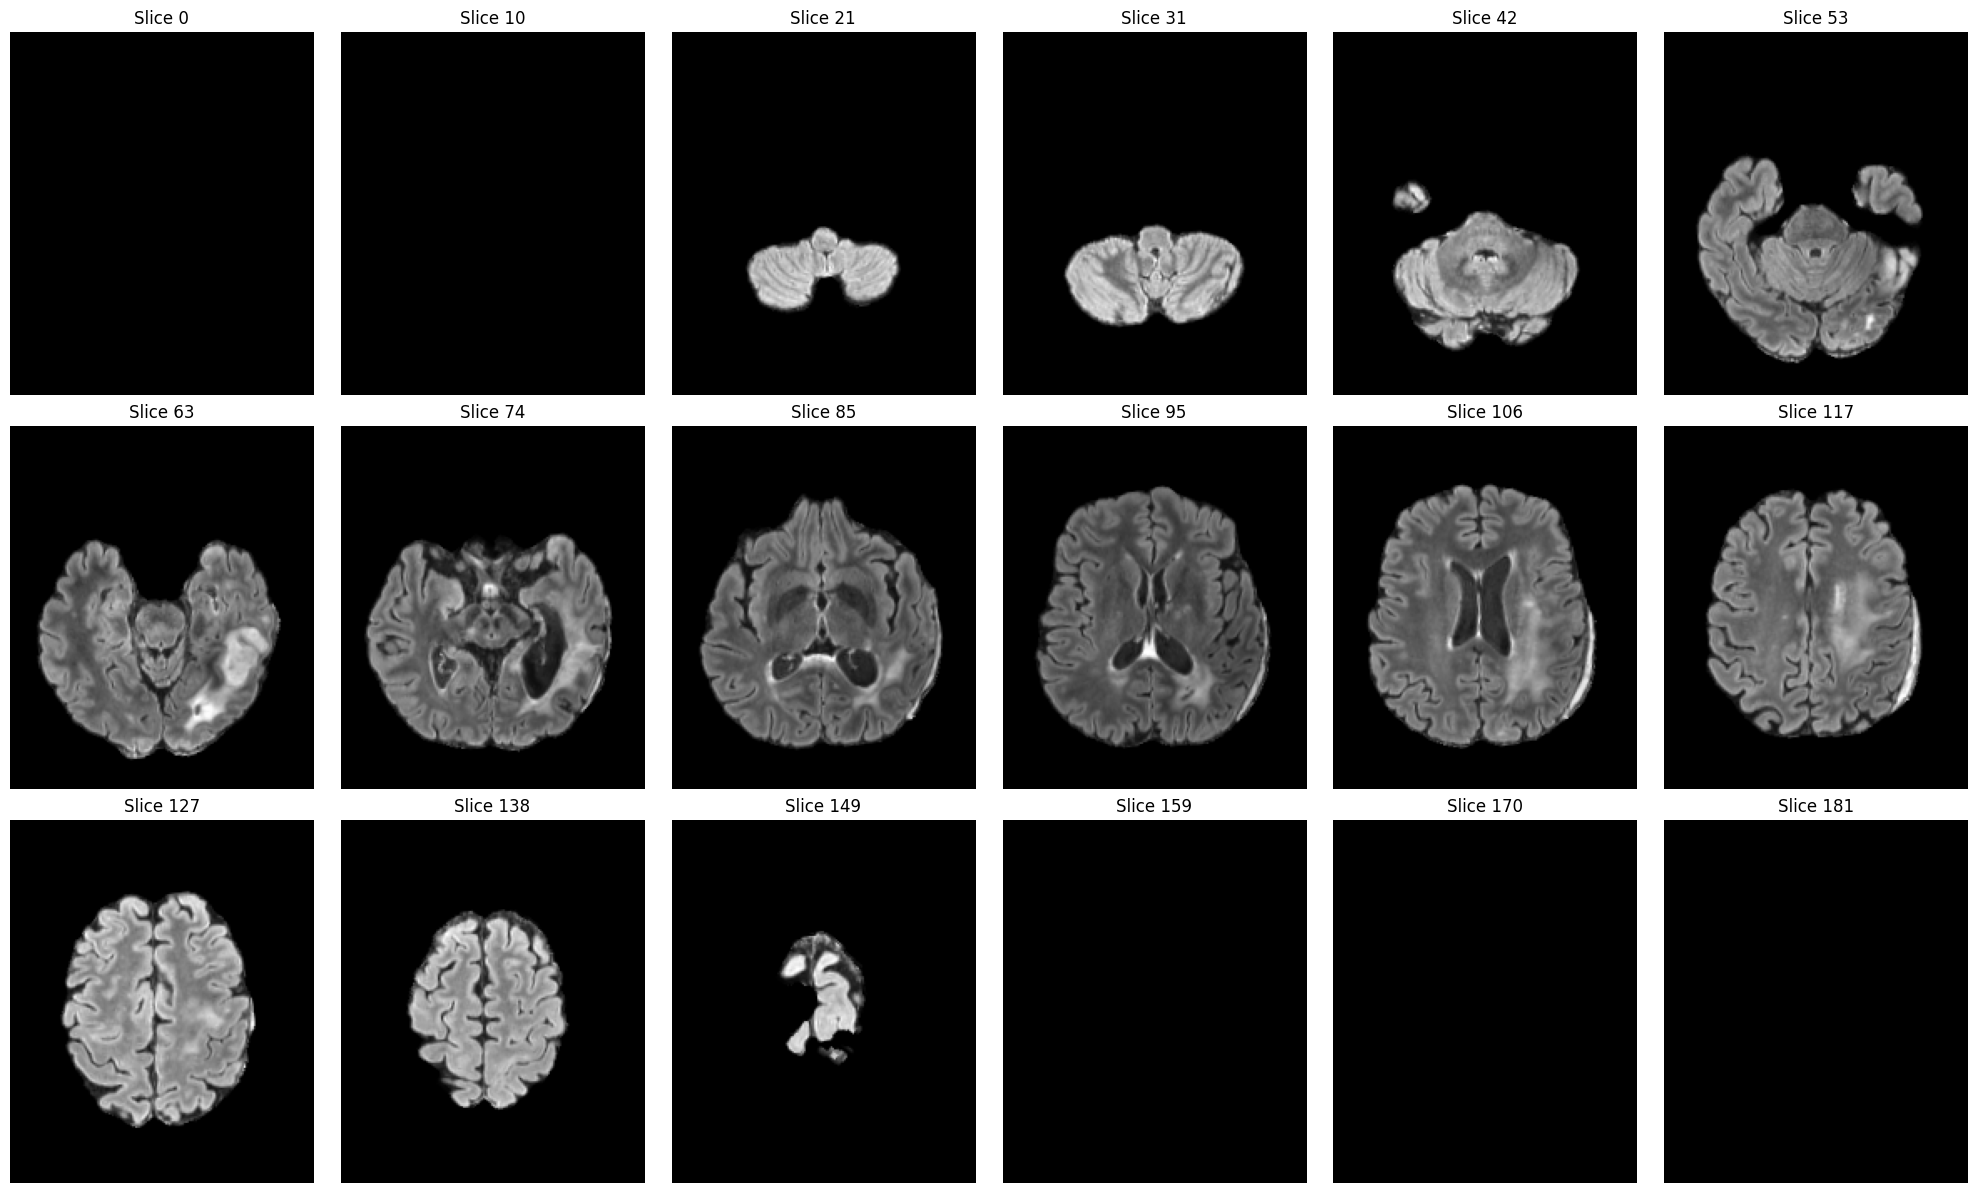

In [18]:
max_space = base_volume.shape[2]
slice_indices = np.linspace(0, max_space - 1, 18, dtype=int)
fig, axes = plt.subplots(3, 6, figsize=(20,12))
axes = axes.flatten()

for i, z_idx in enumerate(slice_indices):
    ax = axes[i]
    ax.imshow(base_volume[:, :, z_idx].T, cmap="gray", origin="lower")
    ax.set_title(f"Slice {z_idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Checking How many pixels i can cut


In [19]:
height, width, num_slices = base_volume.shape

min_top = height
max_bottom = height
min_left = width
min_right = width

top_border = 0
left_border = 0
bottom_border = 182
right_border = 182

counter = 0
empty_slices = []

for z in range(num_slices):
    slice_2d = base_volume[:, :, z]

    if not np.any(slice_2d > 0):
        empty_slices.append(z)
        counter += 1
        continue

    rows, cols = np.where(slice_2d > 0)

    min_r, max_r = rows.min(), rows.max()
    min_c, max_c = cols.min(), cols.max()

    top_dist = min_r
    bottom_dist = bottom_border - max_r
    left_dist = min_c
    right_dist = right_border - max_c

    min_top = min(min_top, top_dist)
    min_bottom = min(min_bottom, bottom_dist)
    min_left = min(min_left, left_dist)
    min_right = min(min_right, right_dist)

safe_height = height - min_top - max_bottom
safe_width = width - min_left - min_right

print(f"Top: {min_top}")
print(f"Bottom: {min_bottom}")
print(f"Left: {min_left}")
print(f"Right: {min_right}")
print(f"Height: {safe_height}")
print(f"Width: {safe_width}")
counter






NameError: name 'min_bottom' is not defined

In [22]:
import json
from tqdm import tqdm # Loading gui

patient_dirs = list_patient_dirs(GLI_ROOT)
patients_z_boundaries = {}


for p_dir in tqdm(patient_dirs, desc="Scanning Z axis"):

    patient_id = p_dir.name
    patient_files = find_patient_files(p_dir)

    if "FLAIR" not in patient_files:
        continue

    volume = nib.load(patient_files["FLAIR"]).get_fdata(dtype=np.float32)

    z_has_brain = np.any(volume > 0, axis=(0, 1))
    brain_indices = np.where(z_has_brain)[0]

    first_z = int(brain_indices[0])
    last_z = int(brain_indices[-1])

    patients_z_boundaries[patient_id] = [first_z, last_z]

output_json_path = DATA_ROOT / "patients_z_boundaries.json"

with open(output_json_path, "w") as f:
    json.dump(patients_z_boundaries, f)


     


Scanning Z axis: 100%|██████████| 1350/1350 [03:36<00:00,  6.23it/s]


## GLI segmentation analysis: 100-patient sample

In [ ]:
from collections import Counter
import random

random.seed(42)

all_gli_patients = list_patient_dirs(GLI_ROOT)
sampled_gli_patients = random.sample(
    all_gli_patients,
    k=100,
)

shape_records = []

for patient_dir in sampled_gli_patients:
    for file_path in patient_dir.glob("*.nii.gz"):
        image = nib.load(file_path)

        shape_records.append({
            "patient_id": patient_dir.name,
            "file": file_path.name,
            "shape": image.shape,
        })

shape_counts = Counter(record["shape"] for record in shape_records)

if len(shape_counts) == 1:
    print("All images have the same shapes")
else:
    print("Images have different shapes")

All images have the same shapes


In [169]:
import random

random.seed(42)

all_gli_patients = list_patient_dirs(GLI_ROOT)
sampled_gli_patients = random.sample(
    all_gli_patients,
    k=100,
)

tumour_records = []

for patient_dir in sampled_gli_patients:
    patient_files = find_patient_files(patient_dir)

    seg = nib.load(patient_files["SEG"]).get_fdata(dtype=np.float32)

    labels, counts = np.unique(seg, return_counts=True)
    label_counts = dict(zip(labels.astype(int), counts))

    total_voxels = seg.size
    segmented_voxels = int((seg != 0).sum())
    whole_tumour_voxels = int(np.isin(seg, [1, 2, 3]).sum())
    tumour_core_voxels = int(np.isin(seg, [1, 3]).sum())
    resection_cavity_voxels = int((seg == 4).sum())

    tumour_records.append({
        "patient_dir": patient_dir,
        "total_voxels": total_voxels,
        "segmented_voxels": segmented_voxels,
        "whole_tumour_voxels": whole_tumour_voxels,
        "tumour_core_voxels": tumour_core_voxels,
        "resection_cavity_voxels": resection_cavity_voxels,
        "whole_tumour_percent": 100 * whole_tumour_voxels / total_voxels,
        "label_counts": label_counts,
        "label_0": label_counts.get(0, 0),
        "label_1": label_counts.get(1, 0),
        "label_2": label_counts.get(2, 0),
        "label_3": label_counts.get(3, 0),
        "label_4": label_counts.get(4, 0),
    })


In [170]:
import pandas as pd

tumour_df = pd.DataFrame(tumour_records)

tumour_df[[
    "segmented_voxels",
    "whole_tumour_voxels",
    "tumour_core_voxels",
    "resection_cavity_voxels",
    "whole_tumour_percent",
    "label_1",
    "label_2",
    "label_3",
    "label_4",
]].describe()

,segmented_voxels,whole_tumour_voxels,tumour_core_voxels,resection_cavity_voxels,whole_tumour_percent,label_1,label_2,label_3,label_4
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,74461.040000,58366.810000,10707.200000,16094.230000,0.808289,1852.180000,47659.610000,8855.020000,16094.230000
std,50346.236143,50075.206973,20612.628271,24365.492458,0.693463,4792.280892,36543.044987,17111.808276,24365.492458
min,1076.000000,1076.000000,0.000000,0.000000,0.014901,0.000000,1076.000000,0.000000,0.000000
25%,38144.750000,24214.250000,0.000000,1779.500000,0.335329,0.000000,20183.000000,0.000000,1779.500000
50%,60485.500000,39474.000000,930.000000,6108.000000,0.546653,0.000000,37667.500000,829.500000,6108.000000
75%,105978.500000,79639.500000,14685.250000,20891.750000,1.102883,1463.500000,62280.250000,11526.250000,20891.750000
max,239092.000000,235573.000000,123886.000000,126450.000000,3.262318,27294.000000,163084.000000,103176.000000,126450.000000


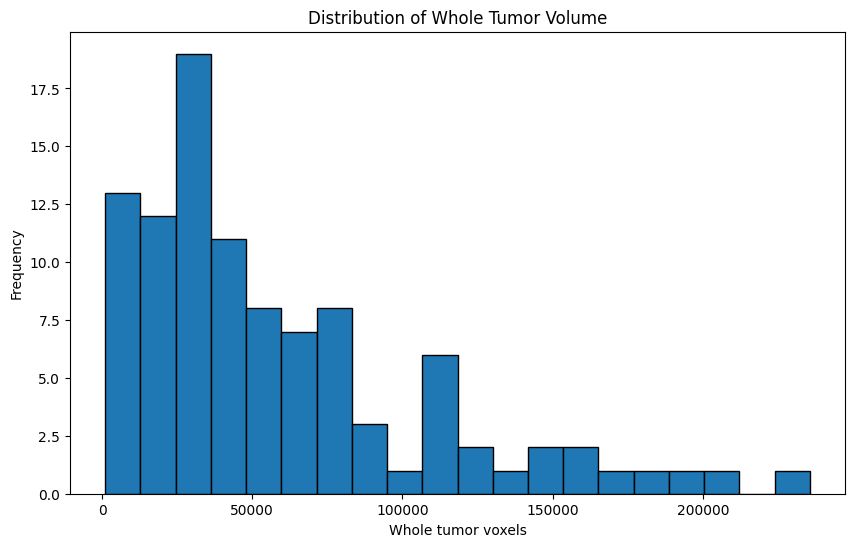

In [171]:
plt.figure(figsize=(10, 6))

plt.hist(tumour_df["whole_tumour_voxels"], bins=20, edgecolor="black")
plt.xlabel("Whole tumor voxels")
plt.ylabel("Frequency")
plt.title("Distribution of Whole Tumor Volume")
plt.show()

In [172]:
class_columns = ["label_1", "label_2", "label_3", "label_4"]

class_totals = tumour_df[class_columns].sum()
class_presence = (tumour_df[class_columns] > 0).sum(axis=0)

print(class_totals)
print(class_presence)

label_1     185218
label_2    4765961
label_3     885502
label_4    1609423
dtype: int64
label_1     43
label_2    100
label_3     68
label_4     89
dtype: int64


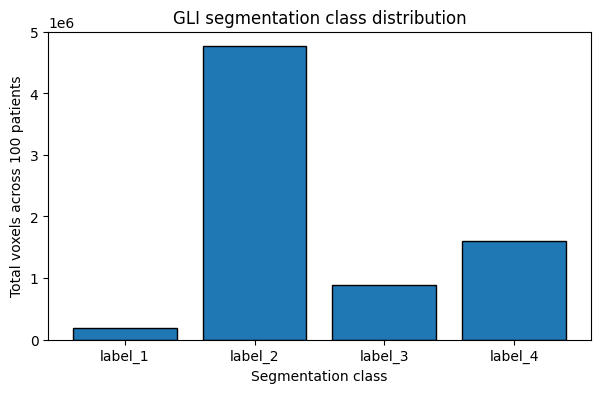

In [173]:
plt.figure(figsize=(7, 4))
plt.bar(class_totals.index, class_totals.values, edgecolor="black")

plt.xlabel("Segmentation class")
plt.ylabel("Total voxels across 100 patients")
plt.title("GLI segmentation class distribution")
plt.show()

In [174]:
for label in [1, 2, 3, 4]:
    tumour_df[f"label_{label}_within_segmentation_percent"] = (
        100 * tumour_df[f"label_{label}"] / tumour_df["segmented_voxels"]
    )

within_segmentation_columns = [
    f"label_{label}_within_segmentation_percent"
    for label in [1, 2, 3, 4]
 ]

tumour_df[within_segmentation_columns].describe()

,label_1_within_segmentation_percent,label_2_within_segmentation_percent,label_3_within_segmentation_percent,label_4_within_segmentation_percent
count,100.000000,100.000000,100.000000,100.000000
mean,1.480072,65.990225,8.876784,23.652919
std,2.978833,21.606115,12.259043,25.315269
min,0.000000,4.033559,0.000000,0.000000
25%,0.000000,51.813533,0.000000,2.025601
50%,0.000000,69.427045,2.081607,13.333448
75%,1.881480,80.953863,15.271574,40.758343
max,18.582010,100.000000,52.393732,95.966441


In [175]:
tumour_df["segmentation_percentage_sum"] = tumour_df[within_segmentation_columns].sum(axis=1)

tumour_df["segmentation_percentage_sum"].describe()

,segmentation_percentage_sum
count,1.000000e+02
mean,1.000000e+02
std,5.531568e-15
min,1.000000e+02
25%,1.000000e+02
50%,1.000000e+02
75%,1.000000e+02
max,1.000000e+02


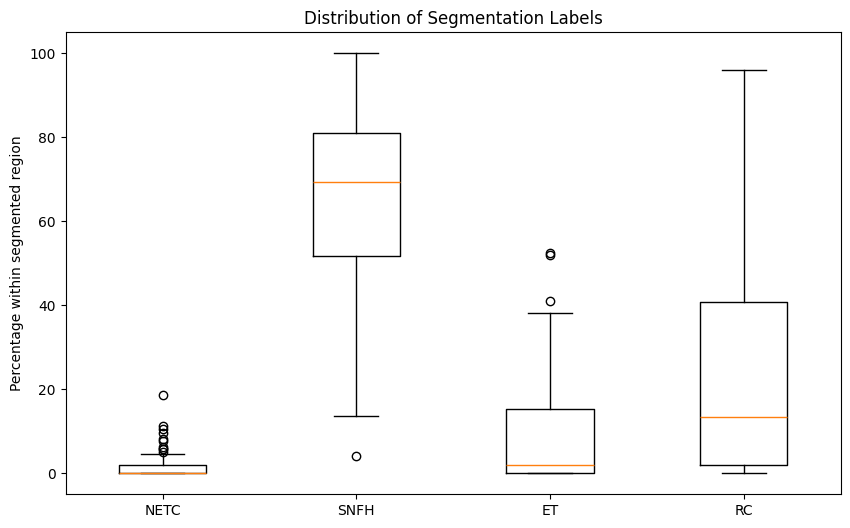

In [176]:
plt.figure(figsize=(10, 6))
plt.boxplot(tumour_df[within_segmentation_columns])
plt.xticks(
    ticks=range(1, 5),
    labels=["NETC", "SNFH", "ET", "RC"],
)
plt.ylabel("Percentage within segmented region")
plt.title("Distribution of Segmentation Labels")
plt.show()

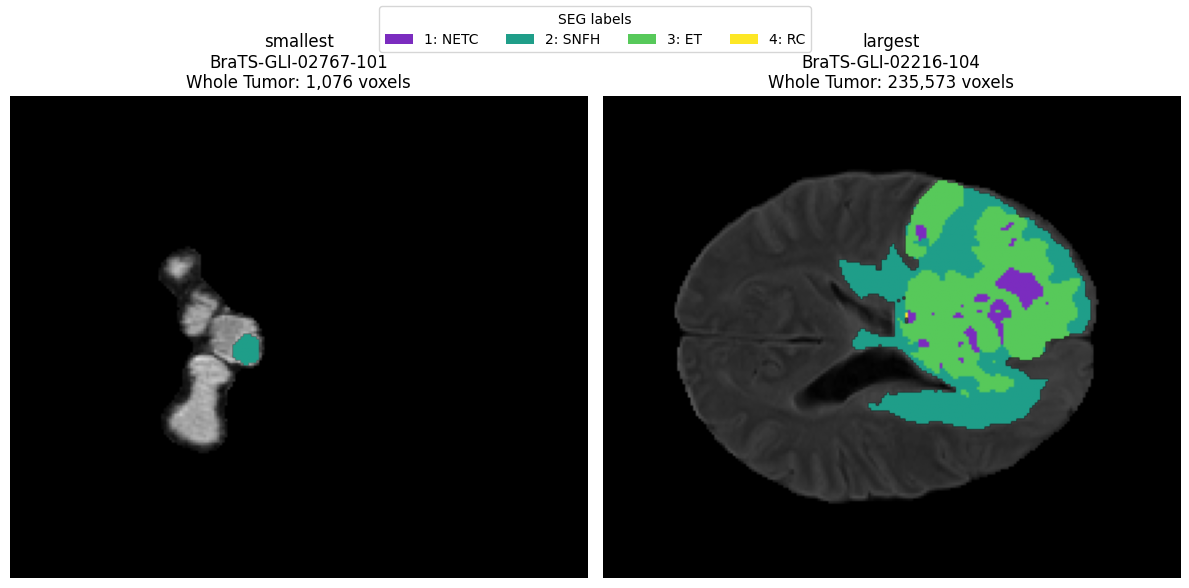

In [207]:
cases = {
    "smallest": tumour_df.loc[
        tumour_df["whole_tumour_voxels"].idxmin()
    ],
    "largest": tumour_df.loc[
        tumour_df["whole_tumour_voxels"].idxmax()
    ],
}

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, (case_name, case_data) in zip(axes, cases.items()):
    patient_dir = case_data["patient_dir"]
    patient_files = find_patient_files(patient_dir)

    flair_volume = nib.load(patient_files["FLAIR"]).get_fdata(dtype=np.float32)
    seg_volume = nib.load(patient_files["SEG"]).get_fdata(dtype=np.float32)

    best_slice = np.argmax(np.sum(seg_volume, axis=(0, 1)))

    masked_seg = np.ma.masked_where(
        seg_volume[:, :, best_slice] == 0,
        seg_volume[:, :, best_slice],
    )

    ax.imshow(flair_volume[:, :, best_slice], cmap="gray")
    ax.imshow(masked_seg, cmap=SEG_CMAP, norm=SEG_NORM, alpha=1.0)
    ax.set_title(
        f"{case_name}\n"
        f"{patient_dir.name}\n"
        f"Whole Tumor: {case_data['whole_tumour_voxels']:,} voxels"
    )
    ax.axis("off")

fig.legend(handles=SEG_LEGEND, loc="upper center", ncol=4, title="SEG labels")
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

In [201]:
intensity_records = []

for patient_dir in sampled_gli_patients:
    patient_files = find_patient_files(patient_dir)

    for modality in ["FLAIR", "T1", "T1CE", "T2"]:
        volume = nib.load(patient_files[modality]).get_fdata(dtype=np.float32)
        non_zero_voxels = volume[volume > 0]

        intensity_records.append({
            "patient_dir": patient_dir.name,
            "modality": modality,
            "mean_intensity": non_zero_voxels.mean(),
            "median_intensity": np.median(non_zero_voxels),
            "std_intensity": non_zero_voxels.std(),
            "min_intensity": non_zero_voxels.min(),
            "max_intensity": non_zero_voxels.max(),
            "q01_intensity": np.quantile(non_zero_voxels, 0.01),
            "q99_intensity": np.quantile(non_zero_voxels, 0.99)
        })

intensity_df = pd.DataFrame(intensity_records)
intensity_df.head()

,patient_dir,modality,mean_intensity,median_intensity,std_intensity,min_intensity,max_intensity,q01_intensity,q99_intensity
0,BraTS-GLI-02062-103,FLAIR,759.639343,771.912842,182.810303,50.168938,1903.480103,173.613342,1140.508423
1,BraTS-GLI-02062-103,T1,1520.183594,1591.590088,478.426514,27.141293,4464.291992,402.868286,2309.333740
2,BraTS-GLI-02062-103,T1CE,1747.993286,1750.827637,604.407837,24.974176,8380.324219,434.896912,4065.193604
3,BraTS-GLI-02062-103,T2,622.082520,537.512207,274.929047,8.537509,1991.270142,314.745270,1737.007812
4,BraTS-GLI-02876-101,FLAIR,671.583557,688.144653,283.169464,66.333252,2278.434082,102.626671,1370.766357


In [209]:
intensity_summary = (
    intensity_df
    .groupby("modality")
    .agg(
        patients=("patient_dir", "count"),
        mean_intensity_mean=("mean_intensity", "mean"),
        mean_intensity_std=("mean_intensity", "std"),
        q01_mean=("q01_intensity", "mean"),
        q99_mean=("q99_intensity", "mean"),
    )
    .round(2)
)

intensity_summary

,patients,mean_intensity_mean,mean_intensity_std,q01_mean,q99_mean
modality,,,,,
FLAIR,100,528.969971,288.170013,61.240002,926.659973
T1,100,1198.859985,831.630005,255.779999,1754.530029
T1CE,100,1375.579956,937.549988,299.809998,2877.320068
T2,100,994.109985,636.919983,210.460007,2498.729980


In [179]:
required_modalities = set(MODALITY_SUFFIXES)

for dataset_name, data_root in [("GLI", GLI_ROOT), ("MEN", MEN_ROOT)]:
    patient_dirs = list_patient_dirs(data_root)
    incomplete_patients = []

    for patient_dir in patient_dirs:
        patient_files = find_patient_files(patient_dir)
        patient_modalities = set(patient_files)
        missing_modalities = required_modalities - patient_modalities

        if missing_modalities:
            incomplete_patients.append(
                (patient_dir.name, missing_modalities))
            
    print(f"\n{dataset_name})")
    print(f"Number of patients: {len(patient_dirs)}")
    print(f"Number of incomplete patients: {len(incomplete_patients)}")

    for patient_id, missing_modalities in incomplete_patients:
        print(f"Patient {patient_id} is missing modalities: {missing_modalities}")


GLI)
Number of patients: 1350
Number of incomplete patients: 0

MEN)
Number of patients: 500
Number of incomplete patients: 500
Patient BraTS-MEN-RT-0100-1 is missing modalities: {'SEG', 'FLAIR', 'T1', 'T2'}
Patient BraTS-MEN-RT-0257-1 is missing modalities: {'SEG', 'FLAIR', 'T1', 'T2'}
Patient BraTS-MEN-RT-0232-1 is missing modalities: {'SEG', 'FLAIR', 'T1', 'T2'}
Patient BraTS-MEN-RT-0178-1 is missing modalities: {'SEG', 'FLAIR', 'T1', 'T2'}
Patient BraTS-MEN-RT-0426-1 is missing modalities: {'SEG', 'FLAIR', 'T1', 'T2'}
Patient BraTS-MEN-RT-0321-1 is missing modalities: {'SEG', 'FLAIR', 'T1', 'T2'}
Patient BraTS-MEN-RT-0296-1 is missing modalities: {'SEG', 'FLAIR', 'T1', 'T2'}
Patient BraTS-MEN-RT-0298-1 is missing modalities: {'SEG', 'FLAIR', 'T1', 'T2'}
Patient BraTS-MEN-RT-0513-1 is missing modalities: {'SEG', 'FLAIR', 'T1', 'T2'}
Patient BraTS-MEN-RT-0395-1 is missing modalities: {'SEG', 'FLAIR', 'T1', 'T2'}
Patient BraTS-MEN-RT-0238-1 is missing modalities: {'SEG', 'FLAIR', 'T1

In [ ]:
!git clone https://github.com/AdaBro24/BraTS_thesis.git /content/BraTS_thesis
!pip install -q nibabel

Cloning into '/content/BraTS_thesis'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 28 (delta 4), reused 27 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 841.74 KiB | 16.19 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [2]:
!git -C /content/BraTS_thesis pull

remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 6 (delta 4), reused 6 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 773 bytes | 154.00 KiB/s, done.
From https://github.com/AdaBro24/BraTS_thesis
   43aa655..6c1bd6d  main       -> origin/main
Updating 43aa655..6c1bd6d
Fast-forward
 src/brain_mri/data/nifti_loader.py | 17 +++++++++++++++--
 1 file changed, 15 insertions(+), 2 deletions(-)


In [3]:
import sys
from pathlib import Path
import numpy as np

sys.path.insert(0, "/content/BraTS_thesis/src")

from brain_mri.data.nifti_loader import load_patient

patient_dir = Path(
    "/content/drive/MyDrive/engineering_thesis/brats/unpacked/"
    "BraTS-GLI/training_data1_v2/BraTS-GLI-02800-101"
)

images, segmentation = load_patient(patient_dir)

print("Images shape:", images.shape)
print("Images dtype:", images.dtype)
print("SEG shape:", segmentation.shape)
print("SEG dtype:", segmentation.dtype)
print("SEG labels:", np.unique(segmentation))

Images shape: (4, 182, 218, 182)
Images dtype: float32
SEG shape: (182, 218, 182)
SEG dtype: int16
SEG labels: [0 2 4]


In [4]:
normalised_flair = images[3]

brain_voxels = normalised_flair[normalised_flair != 0]

print("Mean:", brain_voxels.mean())
print("Std:", brain_voxels.std())
print("Background values:", np.unique(normalised_flair[normalised_flair == 0]))


Mean: -3.2346378e-08
Std: 1.0000001
Background values: [0.]


## MEN single-patient exploration

In [180]:
MODALITY_SUFFIXES["GTV"] = "gtv"
sample_dir = list_patient_dirs(MEN_ROOT)[0]
sample_files = find_patient_files(sample_dir)
print(f"Sample directory: {sample_dir}")
print(f"Sample files: {sample_files}")

Sample directory: /content/drive/MyDrive/engineering_thesis/brats/unpacked/BraTS-MEN/BraTS-MEN-RT-Train-v2/BraTS-MEN-RT-0100-1
Sample files: {'T1CE': PosixPath('/content/drive/MyDrive/engineering_thesis/brats/unpacked/BraTS-MEN/BraTS-MEN-RT-Train-v2/BraTS-MEN-RT-0100-1/BraTS-MEN-RT-0100-1_t1c.nii.gz'), 'GTV': PosixPath('/content/drive/MyDrive/engineering_thesis/brats/unpacked/BraTS-MEN/BraTS-MEN-RT-Train-v2/BraTS-MEN-RT-0100-1/BraTS-MEN-RT-0100-1_gtv.nii.gz')}


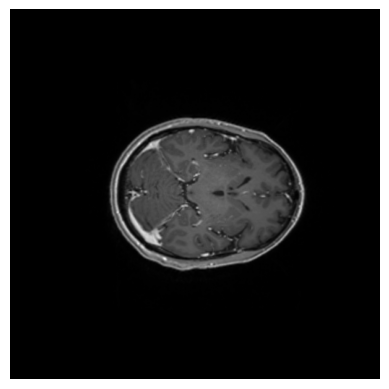

In [181]:
men_volume = nib.load(sample_files['T1CE']).get_fdata(dtype=np.float32)
slice_idx = np.argmax(np.sum(men_volume, axis=(0,1)))
plt.imshow(men_volume[:, :, slice_idx], cmap="grey")
plt.axis('off')
plt.show()

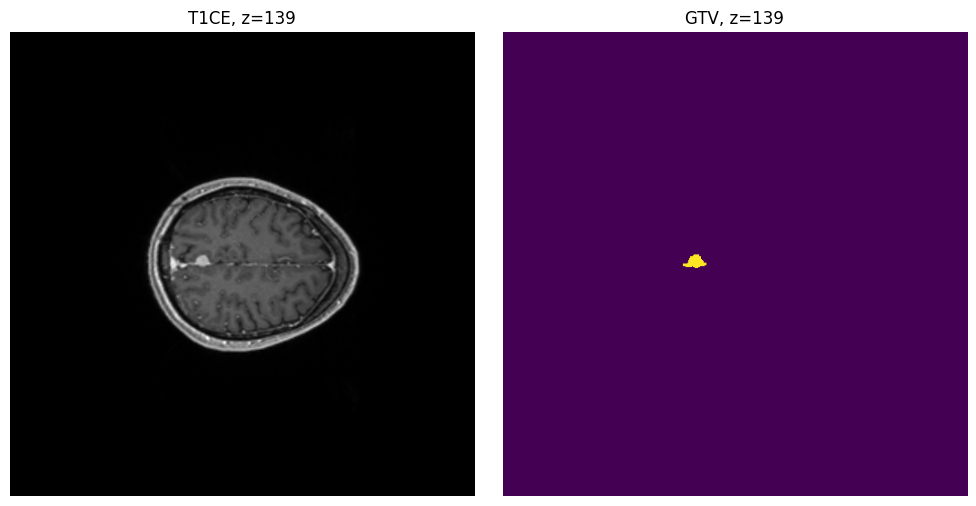

In [182]:
MEN_MODALITIES = ["T1CE", "GTV"]

gtv_volume = nib.load(sample_files["GTV"]).get_fdata(dtype=np.float32)
slice_idx = np.argmax(np.sum(gtv_volume != 0, axis=(0, 1)))

fig, axes = plt.subplots(1, len(MEN_MODALITIES), figsize=(10, 5))

for ax, modality in zip(axes, MEN_MODALITIES):
    volume = nib.load(sample_files[modality]).get_fdata(dtype=np.float32)
    cmap = "viridis" if modality == "GTV" else "gray"

    ax.imshow(volume[:, :, slice_idx], cmap=cmap)
    ax.set_title(f"{modality}, z={slice_idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

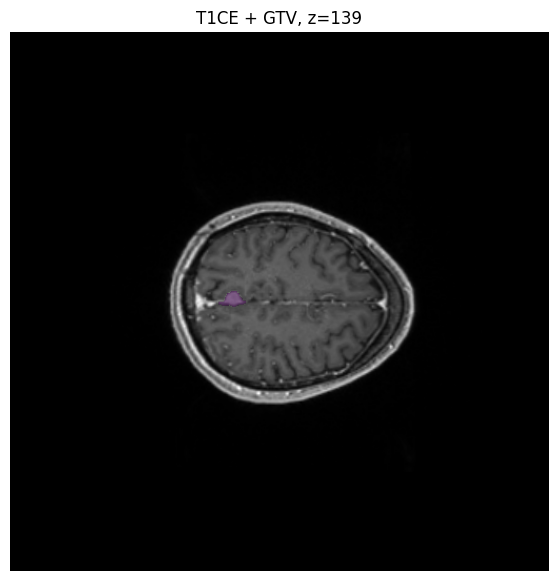

In [183]:
base_modality = 'T1CE'

base_volume = nib.load(sample_files[base_modality]).get_fdata(dtype=np.float32)
gtv_volume = nib.load(sample_files["GTV"]).get_fdata(dtype=np.float32)

slice_idx = np.argmax(np.sum(gtv_volume != 0, axis=(0, 1)))
base_slice = base_volume[:, :, slice_idx]
gtv_slice = gtv_volume[:, :, slice_idx]

masked_gtv = np.ma.masked_where(gtv_slice == 0, gtv_slice)


plt.figure(figsize=(7, 7))
plt.imshow(base_slice, cmap='gray')
plt.imshow(masked_gtv, cmap='viridis', alpha=0.5)
plt.title(f'{base_modality} + GTV, z={slice_idx}')
plt.axis('off')
plt.show()
